### Import Libraries


In [133]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Load The dataset

In [134]:
df=pd.read_csv("marketing_campaign.csv",sep="\t")


### Inicial Data exploration

In [135]:
df.head().T

,0,1,2,3,4
ID,5524,2174,4141,6182,5324
Year_Birth,1957,1954,1965,1984,1981
Education,Graduation,Graduation,Graduation,Graduation,PhD
Marital_Status,Single,Single,Together,Together,Married
Income,58138.0,46344.0,71613.0,26646.0,58293.0
Kidhome,0,1,0,1,1
Teenhome,0,1,0,0,0
Dt_Customer,04-09-2012,08-03-2014,21-08-2013,10-02-2014,19-01-2014
Recency,58,38,26,26,94
MntWines,635,11,426,11,173


In [136]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

In [137]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
ID,2240.0,5592.159821,3246.662198,0.0,2828.25,5458.5,8427.75,11191.0
Year_Birth,2240.0,1968.805804,11.984069,1893.0,1959.00,1970.0,1977.00,1996.0
Income,2216.0,52247.251354,25173.076661,1730.0,35303.00,51381.5,68522.00,666666.0
Kidhome,2240.0,0.444196,0.538398,0.0,0.00,0.0,1.00,2.0
Teenhome,2240.0,0.506250,0.544538,0.0,0.00,0.0,1.00,2.0
Recency,2240.0,49.109375,28.962453,0.0,24.00,49.0,74.00,99.0
MntWines,2240.0,303.935714,336.597393,0.0,23.75,173.5,504.25,1493.0
MntFruits,2240.0,26.302232,39.773434,0.0,1.00,8.0,33.00,199.0
MntMeatProducts,2240.0,166.950000,225.715373,0.0,16.00,67.0,232.00,1725.0
MntFishProducts,2240.0,37.525446,54.628979,0.0,3.00,12.0,50.00,259.0


### Data Cleaning and Preprocessing

In [138]:
df.duplicated().sum()

np.int64(0)

In [139]:
df.isna().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
AcceptedCmp3            0
AcceptedCmp4            0
AcceptedCmp5            0
AcceptedCmp1            0
AcceptedCmp2            0
Complain                0
Z_CostContact           0
Z_Revenue               0
Response                0
dtype: int64

In [140]:
df["Income"].value_counts()

Income
7500.0     12
35860.0     4
18929.0     3
46098.0     3
67445.0     3
           ..
5305.0      1
80617.0     1
38054.0     1
88325.0     1
41769.0     1
Name: count, Length: 1974, dtype: int64

In [141]:
df["Income"].fillna(df["Income"].mean(),inplace=True)

C:\Users\Panneer\AppData\Local\Temp\ipykernel_10272\1733768805.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Income"].fillna(df["Income"].mean(),inplace=True)


In [142]:
df.isna().sum()

ID                     0
Year_Birth             0
Education              0
Marital_Status         0
Income                 0
Kidhome                0
Teenhome               0
Dt_Customer            0
Recency                0
MntWines               0
MntFruits              0
MntMeatProducts        0
MntFishProducts        0
MntSweetProducts       0
MntGoldProds           0
NumDealsPurchases      0
NumWebPurchases        0
NumCatalogPurchases    0
NumStorePurchases      0
NumWebVisitsMonth      0
AcceptedCmp3           0
AcceptedCmp4           0
AcceptedCmp5           0
AcceptedCmp1           0
AcceptedCmp2           0
Complain               0
Z_CostContact          0
Z_Revenue              0
Response               0
dtype: int64

In [143]:
df["Marital_Status"].unique()

array(['Single', 'Together', 'Married', 'Divorced', 'Widow', 'Alone',
       'Absurd', 'YOLO'], dtype=object)

In [144]:
marrital_count=df['Marital_Status'].value_counts()

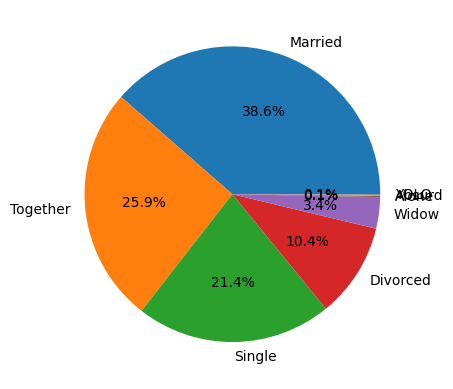

In [145]:
plt.pie(marrital_count,labels=marrital_count.index, autopct='%1.1f%%')
plt.show()

In [146]:
print(df["Marital_Status"].head())

0      Single
1      Single
2    Together
3    Together
4     Married
Name: Marital_Status, dtype: object


In [147]:
df["Marital_Status"]=df["Marital_Status"].astype(str).str.strip().str.capitalize()

In [148]:
df["Marital_group"]=df["Marital_Status"].replace({"Single":"Single","Together":"other",'Married':'Married','Divorced':'other','Widow':'other','Alone':'other','Absurd':'other','YOLO':'other'})

In [149]:
print(df["Marital_group"].head())

0     Single
1     Single
2      other
3      other
4    Married
Name: Marital_group, dtype: object


In [150]:
df["Marital_group"].unique()

array(['Single', 'other', 'Married', 'Yolo'], dtype=object)

In [151]:
mar_count=df["Marital_group"].value_counts()
mar_count

Marital_group
other      894
Married    864
Single     480
Yolo         2
Name: count, dtype: int64

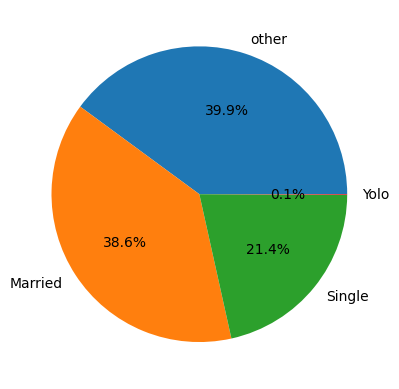

In [155]:
mar_count=df["Marital_group"].value_counts()
plt.pie(mar_count,labels=mar_count.index,autopct="%1.1f%%")
plt.show()

In [163]:
df['age']=2025-df['Year_Birth']

In [164]:
df['age']

0       68
1       71
2       60
3       41
4       44
        ..
2235    58
2236    79
2237    44
2238    69
2239    71
Name: age, Length: 2240, dtype: int64

In [165]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 31 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2240 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

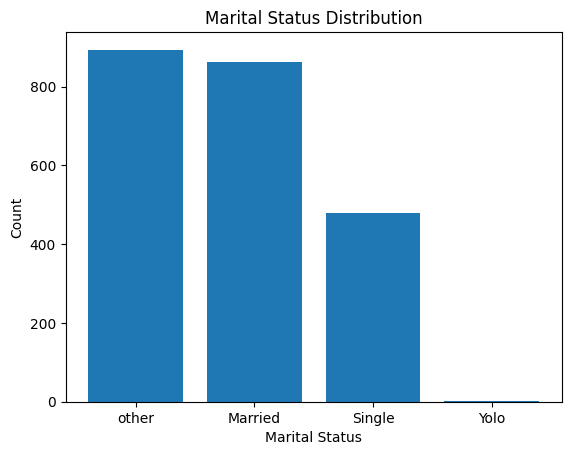

In [172]:
plt.bar(mar_count.index,mar_count.values,label=True)
plt.xlabel("Marital Status")
plt.ylabel("Count")
plt.title("Marital Status Distribution")
plt.show()

C:\Users\Panneer\AppData\Local\Temp\ipykernel_10272\100643567.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df['Marital_group'],y='age',data=df,palette="Set2")


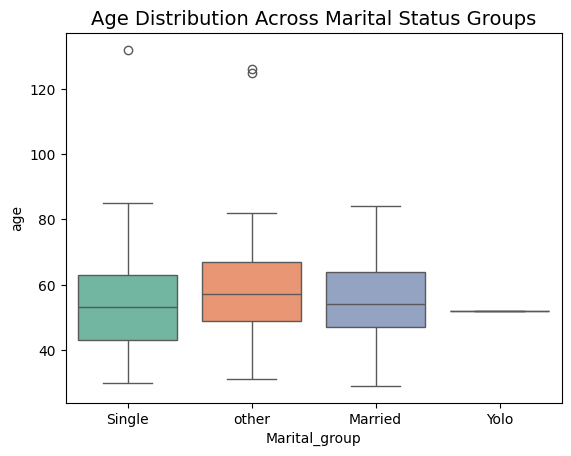

In [179]:
sns.boxplot(x=df['Marital_group'],y='age',data=df,palette="Set2")
plt.title("Age Distribution Across Marital Status Groups", fontsize=14)
plt.show()

C:\Users\Panneer\AppData\Local\Temp\ipykernel_10272\1122870602.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Education', y='Income', palette="Set2")


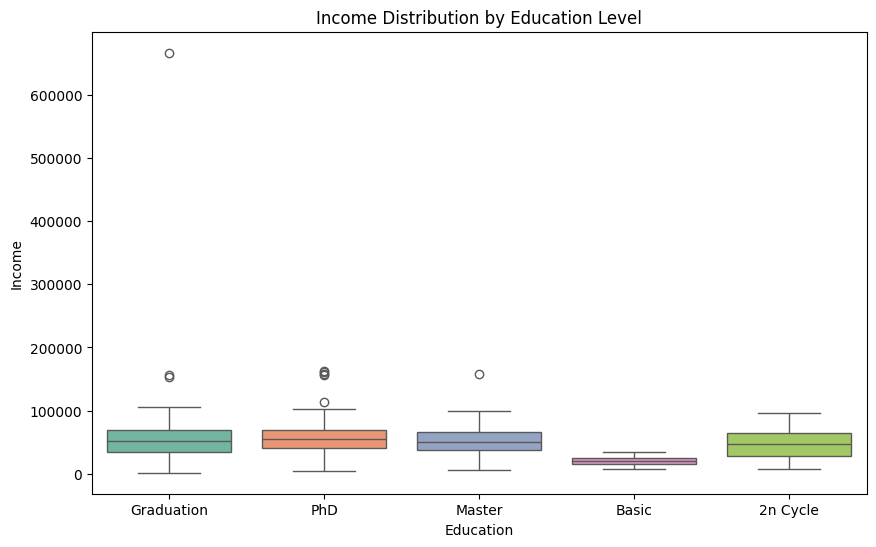

In [183]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='Education', y='Income', palette="Set2")
plt.title('Income Distribution by Education Level')
plt.show()

In [184]:
plt.savefig("Single_vs_marital_status.png")

<Figure size 640x480 with 0 Axes>